# Neural Network Climatology: Global air temperature observations

In this notebook, we model temperature over the global region using all observations.
We load observations data with additional predictors (roughness, land fraction), apply suitable transformations.

Data: 

observations_qc.csv

land_fraction_data.csv

roughness_data.csv

We use additional predictors along with the intially provided covariates to potentially improve learning process of our models.

Model and libraries:

We use tensorflow and keras libraries to build neural network climatology models and evaluate them with MAE metric.
Furthermore, we create various visual plots to analyse the results.


## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import norm

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Libraries for Neural Networks
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras import layers, models
import datetime
from tensorflow.keras.callbacks import TensorBoard
import keras
print(tf.__version__)

import keras_tuner
import math

2.19.0


## Loading Observations and additional predictors

In [4]:
obs = pd.read_csv('./datasets/observations_qc.csv', compression="gzip", parse_dates=["time"])
land_frac_data = pd.read_csv('./datasets/land_fraction_data.csv', compression="gzip")
roughness_data = pd.read_csv('./datasets/roughness_data.csv', compression="gzip")

obs = obs.merge(land_frac_data, how='left', on=['wmo_id','latitude','longitude', 'altitude'])
obs = obs.merge(roughness_data, how='left', on=['wmo_id','latitude','longitude', 'altitude'])

print(obs.shape)
print(obs.columns)
print((obs['ob_value']-273.15).min())
print((obs['ob_value']-273.15).max())

(9232630, 9)
Index(['ob_value', 'time', 'wmo_id', 'diagnostic', 'latitude', 'longitude',
       'altitude', 'land_fraction', 'roughness'],
      dtype='object')
-79.64999999999998
58.25


## Data Transformations

In [6]:
# Transforming date to a cyclic pattern in a 365 day cycle
obs['day_of_year'] = obs['time'].dt.dayofyear
obs['hour'] = pd.to_datetime(obs['time']).dt.hour

#obs['sin_day'] = np.sin(2 * np.pi * (obs['day_of_year'] + obs['hour']/24) / 365).round(5)
#obs['cos_day'] = np.cos(2 * np.pi * (obs['day_of_year'] + obs['hour']/24) / 365).round(5)

obs['sin_day'] = np.sin(2 * np.pi * obs['day_of_year'] / 365).round(5)
obs['cos_day'] = np.cos(2 * np.pi * obs['day_of_year'] / 365).round(5)

# Transforming time to a cyclic pattern - 24 hour cycle by calculating the solar time at positions
obs['sin_hour'] = np.sin(2 * np.pi * (obs['hour'] + 24 * (obs['longitude'] / 360)) / 24).round(5)
obs['cos_hour'] = np.cos(2 * np.pi * (obs['hour'] + 24 * (obs['longitude'] / 360)) / 24).round(5)


In [7]:
# Transforming latitude, longitude to [-1,1] range
obs['lat'] = (obs['latitude']/90.0).round(5)
obs['sin_long'] = np.sin(np.radians(obs['longitude'])).round(5)
obs['cos_long'] = np.cos(np.radians(obs['longitude'])).round(5)

obs['temp_celcius'] = obs['ob_value'] - 273.15

In [8]:
obs.head(10)

,ob_value,time,wmo_id,diagnostic,latitude,longitude,altitude,land_fraction,roughness,day_of_year,hour,sin_day,cos_day,sin_hour,cos_hour,lat,sin_long,cos_long,temp_celcius
0,255.0,2025-02-01 02:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,2,0.52342,0.85208,-0.76034,0.64953,-0.93333,-0.98324,0.18234,-18.15
1,254.8,2025-02-01 04:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,4,0.52342,0.85208,-0.33371,0.94268,-0.93333,-0.98324,0.18234,-18.35
2,255.3,2025-02-01 06:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,6,0.52342,0.85208,0.18234,0.98324,-0.93333,-0.98324,0.18234,-17.85
3,255.5,2025-02-01 07:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,7,0.52342,0.85208,0.43061,0.90254,-0.93333,-0.98324,0.18234,-17.65
4,255.3,2025-02-01 08:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,8,0.52342,0.85208,0.64953,0.76034,-0.93333,-0.98324,0.18234,-17.85
5,254.5,2025-02-01 09:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,9,0.52342,0.85208,0.82419,0.56632,-0.93333,-0.98324,0.18234,-18.65
6,254.5,2025-02-01 10:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,10,0.52342,0.85208,0.94268,0.33371,-0.93333,-0.98324,0.18234,-18.65
7,254.1,2025-02-01 12:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,12,0.52342,0.85208,0.98324,-0.18234,-0.93333,-0.98324,0.18234,-19.05
8,253.6,2025-02-01 13:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,13,0.52342,0.85208,0.90254,-0.43061,-0.93333,-0.98324,0.18234,-19.55
9,255.4,2025-02-01 19:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,19,0.52342,0.85208,-0.43061,-0.90254,-0.93333,-0.98324,0.18234,-17.75


## Climatology: Neural Network Model using TensorFlow

### Data Preparation

In [11]:
df = obs.copy()
print(df.columns)
df.head(5)

Index(['ob_value', 'time', 'wmo_id', 'diagnostic', 'latitude', 'longitude',
       'altitude', 'land_fraction', 'roughness', 'day_of_year', 'hour',
       'sin_day', 'cos_day', 'sin_hour', 'cos_hour', 'lat', 'sin_long',
       'cos_long', 'temp_celcius'],
      dtype='object')


,ob_value,time,wmo_id,diagnostic,latitude,longitude,altitude,land_fraction,roughness,day_of_year,hour,sin_day,cos_day,sin_hour,cos_hour,lat,sin_long,cos_long,temp_celcius
0,255.0,2025-02-01 02:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,2,0.52342,0.85208,-0.76034,0.64953,-0.93333,-0.98324,0.18234,-18.15
1,254.8,2025-02-01 04:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,4,0.52342,0.85208,-0.33371,0.94268,-0.93333,-0.98324,0.18234,-18.35
2,255.3,2025-02-01 06:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,6,0.52342,0.85208,0.18234,0.98324,-0.93333,-0.98324,0.18234,-17.85
3,255.5,2025-02-01 07:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,7,0.52342,0.85208,0.43061,0.90254,-0.93333,-0.98324,0.18234,-17.65
4,255.3,2025-02-01 08:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,8,0.52342,0.85208,0.64953,0.76034,-0.93333,-0.98324,0.18234,-17.85


In [13]:
#Splitting dataset into train, test and validation set with a ratio of 70:15:15.
unique_wmo_ids = df['wmo_id'].unique()
unique_wmo_ids.shape
np.random.seed(0)
np.random.shuffle(unique_wmo_ids)

#Splitting data by 70-30 ratio
split_index = int(0.7 * len(unique_wmo_ids))
train_ids = unique_wmo_ids[:split_index]

split_index_1 = int(0.5 * (len(unique_wmo_ids) - len(train_ids)))
val_ids = unique_wmo_ids[split_index : (split_index + split_index_1)]
test_ids = unique_wmo_ids[(split_index + split_index_1):]

df_train = df[df['wmo_id'].isin(train_ids)]
df_val = df[df['wmo_id'].isin(val_ids)]
df_test = df[df['wmo_id'].isin(test_ids)]

print(train_ids.shape)
print(val_ids.shape)
print(test_ids.shape)
print(df_train.shape)
print(df_val.shape)
print(df_test.shape)


(5499,)
(1178,)
(1179,)
(6432675, 19)
(1397845, 19)
(1402110, 19)


### Visualising train, test, val sites and storing data for visualisations

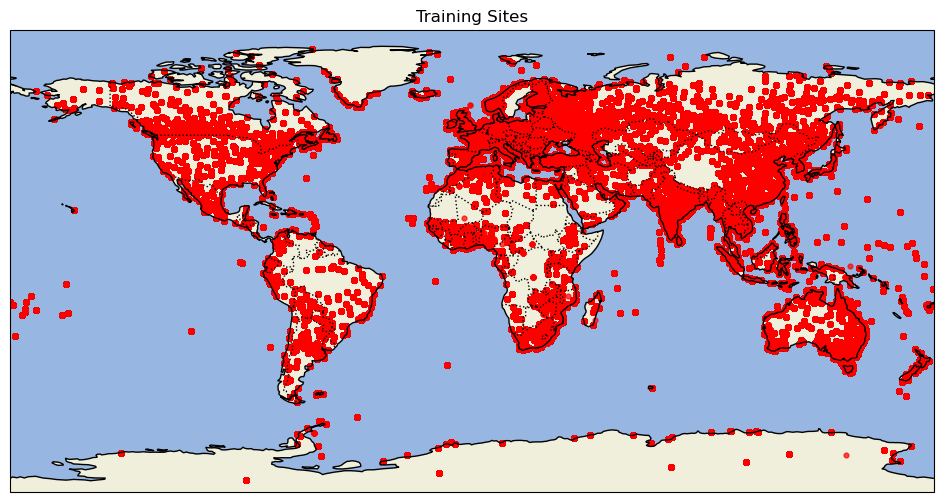

In [15]:
# Create a map
plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
#ax.set_extent([-11, 3, 49.5, 61.5], crs=ccrs.PlateCarree())
# Add features: coastlines, borders, land, ocean
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)
ax.set_global()

# Plot points
ax.scatter(df_train['longitude'], df_train['latitude'], color='red', s=12, alpha=0.7, transform=ccrs.PlateCarree())

plt.title("Training Sites")
plt.show()

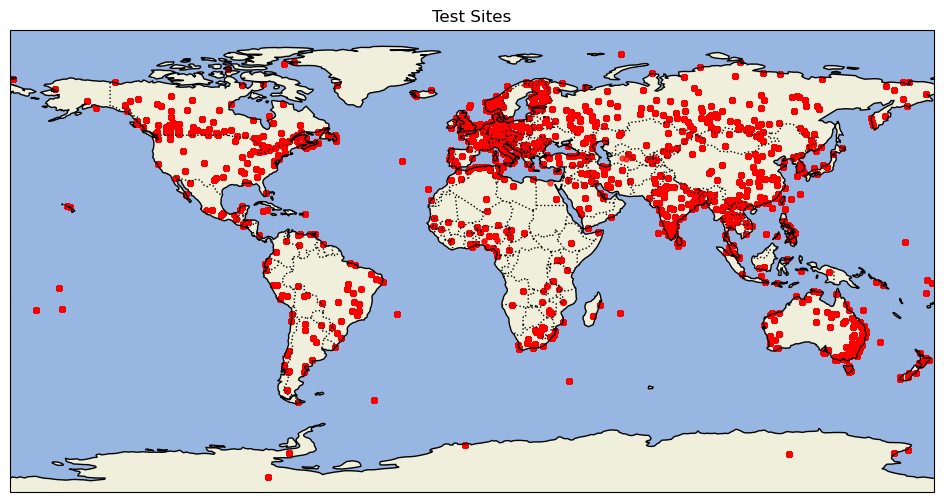

In [23]:
# Create a map
plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
#ax.set_extent([-11, 3, 49.5, 61.5], crs=ccrs.PlateCarree())
# Add features: coastlines, borders, land, ocean
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)
ax.set_global()

# Plot points
ax.scatter(df_test['longitude'], df_test['latitude'], color='red', s=12, alpha=0.7, transform=ccrs.PlateCarree())

plt.title("Test Sites")
plt.show()

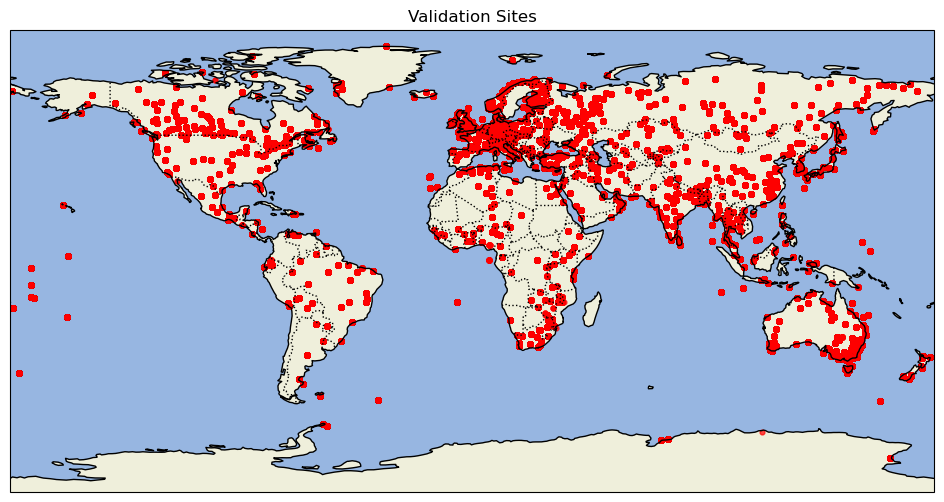

In [25]:
# Create a map
plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
#ax.set_extent([-11, 3, 49.5, 61.5], crs=ccrs.PlateCarree())
# Add features: coastlines, borders, land, ocean
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)
ax.set_global()

# Plot points
ax.scatter(df_val['longitude'], df_val['latitude'], color='red', s=12, alpha=0.7, transform=ccrs.PlateCarree())

plt.title("Validation Sites")
plt.show()

In [27]:
map_values = df_test[['latitude', 'longitude','altitude', 'temp_celcius', 'day_of_year']]
map_values

,latitude,longitude,altitude,temp_celcius,day_of_year
0,-84.000,-79.494,1285.0,-18.15,32
1,-84.000,-79.494,1285.0,-18.35,32
2,-84.000,-79.494,1285.0,-17.85,32
3,-84.000,-79.494,1285.0,-17.65,32
4,-84.000,-79.494,1285.0,-17.85,32
...,...,...,...,...,...
9232600,80.626,58.059,21.0,-6.35,139
9232613,80.626,58.059,21.0,-6.75,140
9232614,80.626,58.059,21.0,-6.85,140
9232626,80.626,58.059,21.0,-6.05,140


### Training Data

In [29]:
df_train = df_train.drop(columns=['ob_value', 'time', 'wmo_id', 'diagnostic', 'latitude', 'longitude', 'day_of_year', 'hour'])
df_val = df_val.drop(columns=['ob_value', 'time', 'wmo_id', 'diagnostic', 'latitude', 'longitude', 'day_of_year', 'hour'])
df_test = df_test.drop(columns=['ob_value', 'time', 'wmo_id', 'diagnostic', 'latitude', 'longitude', 'day_of_year', 'hour'])

df_test

,altitude,land_fraction,roughness,sin_day,cos_day,sin_hour,cos_hour,lat,sin_long,cos_long,temp_celcius
0,1285.0,1.000000,0.000615,0.52342,0.85208,-0.76034,0.64953,-0.93333,-0.98324,0.18234,-18.15
1,1285.0,1.000000,0.000615,0.52342,0.85208,-0.33371,0.94268,-0.93333,-0.98324,0.18234,-18.35
2,1285.0,1.000000,0.000615,0.52342,0.85208,0.18234,0.98324,-0.93333,-0.98324,0.18234,-17.85
3,1285.0,1.000000,0.000615,0.52342,0.85208,0.43061,0.90254,-0.93333,-0.98324,0.18234,-17.65
4,1285.0,1.000000,0.000615,0.52342,0.85208,0.64953,0.76034,-0.93333,-0.98324,0.18234,-17.85
...,...,...,...,...,...,...,...,...,...,...,...
9232600,21.0,0.033826,0.030000,0.68077,-0.73249,0.22595,0.97414,0.89584,0.84859,0.52905,-6.35
9232613,21.0,0.033826,0.030000,0.66806,-0.74410,0.84859,0.52905,0.89584,0.84859,0.52905,-6.75
9232614,21.0,0.033826,0.030000,0.66806,-0.74410,0.97414,-0.22595,0.89584,0.84859,0.52905,-6.85
9232626,21.0,0.033826,0.030000,0.66806,-0.74410,0.52905,-0.84859,0.89584,0.84859,0.52905,-6.05


In [31]:
X_train = df_train.iloc[:, :10].values
y_train = df_train.iloc[:, 10].values
X_val = df_val.iloc[:, :10].values
y_val = df_val.iloc[:, 10].values
X_test = df_test.iloc[:, :10].values
y_test = df_test.iloc[:, 10].values

print(y_test.max())

47.35000000000002


In [33]:
#do this for neural networks
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

X_train.shape

(6432675, 10)

### Define a model, loss, metrics, optimiser

Define a model here or run the next section to obtain an optimised model specification

In [29]:

tf.random.set_seed(0)

model = models.Sequential([
    layers.Dense(416, activation='sigmoid'),
    layers.Dense(288, activation='sigmoid'),
    layers.Dense(448, activation='sigmoid'),
    layers.Dense(192, activation='sigmoid'),
    layers.Dense(160, activation='sigmoid'),
    layers.Dense(1)  
])

In [30]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(
    optimizer=optimizer,
    loss='mean_squared_error',      
    metrics=['mean_absolute_error']
)

print("Available devices:", tf.config.list_physical_devices())

Available devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


### Optimal Model Selection using Keras Tuner

*References:*
https://keras.io/keras_tuner/

https://keras.io/keras_tuner/getting_started/

https://www.tensorflow.org/tutorials/keras/keras_tuner

https://medium.com/@piyushkashyap045/mastering-hyperparameter-tuning-for-neural-networks-with-keras-tuner-c0b64d549188


Learing Rate optimisation:
choice: geometric mean of learning rates
1e-3, 

In [465]:
def build_model(hp):
    model = keras.Sequential()
    
    # Tune the number of units in the first four dense layers
    # Choose an optimal value between 32-512

    for i in range(hp.Int('num_layers', 5, 7)):
        model.add(keras.layers.Dense(units=hp.Int(f'units_{i}', min_value=32, max_value=512, step=32), activation = 'sigmoid'))
                                     #activation=hp.Choice(f'activation_{i}', ['relu', 'sigmoid'])))
    
    model.add(keras.layers.Dense(1))
    # Tune the learning rate for the optimizer
    # Choose an optimal value from 0.01, 0.001, or 0.0001
    hp_learning_rate = hp.Choice('learning_rate', values=[5*1e-4, 1e-4, 5*1e-5])
    #loss_choice = hp.Choice('loss', values=['mean_squared_error', ''])
    
    
    #model.compile(loss='mean_squared_error', optimizer=hp.Choice('optimizer', values=['Adam', 'sgd']), metrics=['mean_absolute_error'])
    model.compile(loss='mean_squared_error', optimizer='Adam', metrics=['mean_absolute_error'])
    return model
    

In [467]:
build_model(keras_tuner.HyperParameters())

<Sequential name=sequential_1, built=False>

#### Using Hyperband algorithm

In [470]:
tuner = keras_tuner.Hyperband(
    build_model,
    max_epochs=10,
    factor=3,
    objective='val_loss',
    directory="my_dir",
    overwrite=True,
    project_name="model_tuning_hyperband")

In [472]:
stopping_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=6)

tuner.search(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[stopping_callback]
)

Trial 30 Complete [00h 04m 45s]
val_loss: 3.850475549697876

Best val_loss So Far: 3.847311496734619
Total elapsed time: 00h 35m 49s


In [476]:

# Get the optimal hyperparameters
best_hps=tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
The hyperparameter search is complete. The optimal number of units in the first densely-connected
layer is {best_hps.get('units_0')} and the optimal learning rate for the optimizer
is {best_hps.get('learning_rate')}.
""")
print(best_hps.get('num_layers'))
print(best_hps.get('units_0'))
print(best_hps.get('units_1'))
print(best_hps.get('units_2'))
print(best_hps.get('units_3'))
print(best_hps.get('units_4'))
#print(best_hps.get('optimizer'))
#print(best_hps.get('activation_0'))
#print(best_hps.get('activation_1'))
#print(best_hps.get('activation_2'))
#print(best_hps.get('activation_2'))
best_hps.get('learning_rate')



The hyperparameter search is complete. The optimal number of units in the first densely-connected
layer is 416 and the optimal learning rate for the optimizer
is 0.0001.

5
416
288
448
192
160


0.0001

In [478]:
model = tuner.hypermodel.build(best_hps)

In [ ]:
!rm -rf logs/

log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
stopping_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=6)

history = model.fit(
    X_train, y_train,
    epochs=400,
    batch_size=64,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=[tensorboard_callback, stopping_callback]
)

#### Using Random Search Algorithm

In [89]:
tuner = keras_tuner.RandomSearch(
    hypermodel=build_model,
    objective='val_loss',
    max_trials=5,
    executions_per_trial=2,
    overwrite=True,
    directory="my_dir",
    project_name="model_tuning")

In [91]:
tuner.search_space_summary()

Search space summary
Default search space size: 5
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 4, 'step': 1, 'sampling': 'linear'}
units_0 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 512, 'step': 32, 'sampling': 'linear'}
activation (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'sigmoid'], 'ordered': False}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}
optimizer (Choice)
{'default': 'Adam', 'conditions': [], 'values': ['Adam', 'sgd'], 'ordered': False}


In [93]:
tuner.search(X_train, y_train, epochs=5, validation_data=(X_val, y_val))

Trial 5 Complete [00h 08m 46s]
val_loss: 13.733267307281494

Best val_loss So Far: 13.733267307281494
Total elapsed time: 00h 45m 45s


In [99]:
# Get the top 2 models.
models = tuner.get_best_models(num_models=2)
best_model = models[1]
best_model.summary()

/opt/anaconda3/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 416)            │         3,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           417 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,161 (16.25 KB)

 Trainable params: 4,161 (16.25 KB)

 Non-trainable params: 0 (0.00 B)

In [97]:
tuner.results_summary()

Results summary
Results in my_dir/model_tuning
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 4 summary
Hyperparameters:
num_layers: 1
units_0: 288
activation: relu
learning_rate: 0.0001
optimizer: Adam
units_1: 288
units_2: 288
Score: 13.733267307281494

Trial 0 summary
Hyperparameters:
num_layers: 1
units_0: 416
activation: sigmoid
learning_rate: 0.01
optimizer: sgd
Score: 14.03691577911377

Trial 2 summary
Hyperparameters:
num_layers: 2
units_0: 320
activation: sigmoid
learning_rate: 0.001
optimizer: Adam
units_1: 448
Score: 14.139615058898926

Trial 1 summary
Hyperparameters:
num_layers: 2
units_0: 32
activation: relu
learning_rate: 0.0001
optimizer: Adam
units_1: 32
Score: 17.21046543121338

Trial 3 summary
Hyperparameters:
num_layers: 3
units_0: 480
activation: relu
learning_rate: 0.01
optimizer: sgd
units_1: 128
units_2: 32
Score: nan


### Training

In [ ]:
!rm -rf logs/

log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
stopping_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7)

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=64,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=[tensorboard_callback, stopping_callback]
)

Epoch 1/200
100511/100511 ━━━━━━━━━━━━━━━━━━━━ 219s 2ms/step - loss: 77.0381 - mean_absolute_error: 6.2368 - val_loss: 41.9365 - val_mean_absolute_error: 4.8147
Epoch 2/200
100511/100511 ━━━━━━━━━━━━━━━━━━━━ 226s 2ms/step - loss: 46.1834 - mean_absolute_error: 4.7412 - val_loss: 36.8129 - val_mean_absolute_error: 4.4831
Epoch 3/200
100511/100511 ━━━━━━━━━━━━━━━━━━━━ 227s 2ms/step - loss: 42.6053 - mean_absolute_error: 4.4846 - val_loss: 35.6701 - val_mean_absolute_error: 4.3869
Epoch 4/200
100511/100511 ━━━━━━━━━━━━━━━━━━━━ 223s 2ms/step - loss: 41.4449 - mean_absolute_error: 4.3925 - val_loss: 34.9163 - val_mean_absolute_error: 4.3119
Epoch 5/200
100511/100511 ━━━━━━━━━━━━━━━━━━━━ 211s 2ms/step - loss: 40.6303 - mean_absolute_error: 4.3178 - val_loss: 33.6179 - val_mean_absolute_error: 4.1938
Epoch 6/200
100511/100511 ━━━━━━━━━━━━━━━━━━━━ 225s 2ms/step - loss: 39.5512 - mean_absolute_error: 4.2140 - val_loss: 32.5932 - val_mean_absolute_error: 4.0959
Epoch 7/200
100511/100511 ━━━━━━━━

In [521]:
train_loss = history.history['loss']
train_mae = history.history['mean_absolute_error']
val_loss = history.history['val_loss']
val_mae = history.history['val_mean_absolute_error']

In [280]:
np.save('./saved_history/newpred_nn_v1_uk_train_loss_.npy', np.array(train_loss))
np.save('./saved_history/newpred_nn_v1_uk_train_mae.npy', np.array(train_mae))
np.save('./saved_history/newpred_nn_v1_uk_val_loss.npy', np.array(val_loss))
np.save('./saved_history/newpred_nn_v1_uk_val_mae.npy', np.array(val_mae))

In [482]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 416)            │         4,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 288)            │       120,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 448)            │       129,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 192)            │        86,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 160)            │        30,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │           161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,114,181 (4.25 MB)

 Trainable params: 371,393 (1.42 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 742,788 (2.83 MB)

### Save model and check results

In [484]:
model.save('./saved_models/newpred_nn_v2.keras')

In [ ]:
train_loss = np.load('./saved_history/hpc_model_v1_train_loss.npy')
train_mae = np.load('./saved_history/hpc_model_v1_train_mae.npy')
val_loss = np.load('./saved_history/hpc_model_v1_val_loss.npy')
val_mae = np.load('./saved_history/hpc_model_v1_val_mae.npy')

#train_loss2 = np.load('./saved_history/hpc_model_v1_train_loss_v2.npy')
#train_mae2 = np.load('./saved_history/hpc_model_v1_train_mae_v2.npy')
#val_loss2 = np.load('./saved_history/hpc_model_v1_val_loss_v2.npy')
#val_mae2 = np.load('./saved_history/hpc_model_v1_val_mae_v2.npy')

#total_train_loss = np.concatenate([train_loss1, train_loss2])
#total_train_mae = np.concatenate([train_mae1, train_mae2])
#total_val_loss = np.concatenate([val_loss1, val_loss2])
#total_val_mae = np.concatenate([val_mae1, val_mae2])

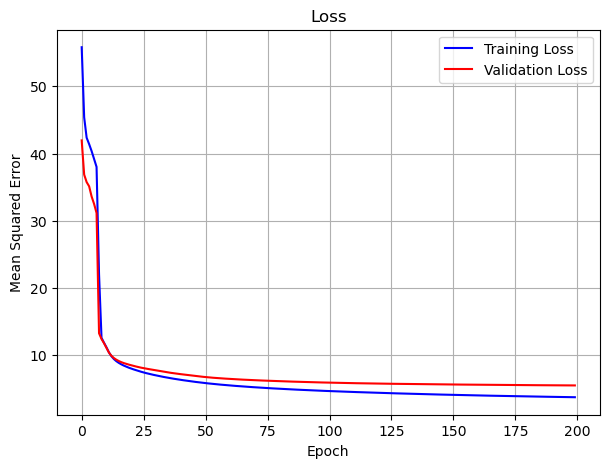

In [243]:
plt.figure(figsize=(7,5))
plt.plot(train_loss, color='blue', label='Training Loss')
plt.plot(val_loss, color='red', label='Validation Loss')
plt.title('Loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.grid(True)

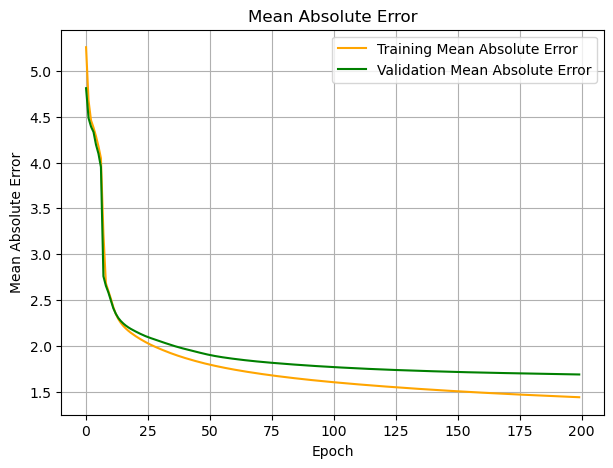

In [245]:
plt.figure(figsize=(7,5))
plt.plot(train_mae, color='orange', label='Training Mean Absolute Error')
plt.plot(val_mae, color='green', label='Validation Mean Absolute Error')
plt.title('Mean Absolute Error')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.grid(True)

### Model Evaluation

In [46]:
model = tf.keras.models.load_model('./saved_models/newpred_nn_v2.keras')

In [48]:
test_loss, test_mae = model.evaluate(X_test, y_test)
print(f"Test MAE: {test_mae:.4f}")


43816/43816 ━━━━━━━━━━━━━━━━━━━━ 20s 443us/step - loss: 8.8857 - mean_absolute_error: 1.8629
Test MAE: 1.7312


In [50]:
preds = model.predict(X_test)

43816/43816 ━━━━━━━━━━━━━━━━━━━━ 17s 390us/step


### Visualisation of results

In [65]:
## creating a dataframe to store visualise outputs and plot against predictors
tempdf = pd.DataFrame({
    'latitude' : map_values['latitude'],
    'longitude' : map_values['longitude'],
    'altitude' : map_values['altitude'],
    'day_of_year' : map_values['day_of_year'],
    'y_test' : y_test,
    'predicted' : preds.reshape(-1),
    'error' : y_test-preds.reshape(-1)
})

tempdf_grouped = tempdf.groupby(['y_test'], as_index = False).agg({
    'predicted' : ['mean', 'std', 'median']
})
tempdf_grouped

y_test  predicted                     
                  mean       std     median
0    -77.85 -71.886292       NaN -71.886292
1    -77.35 -73.897827  2.286040 -73.897827
2    -77.15 -73.018234  3.404694 -73.018234
3    -76.95 -72.487923  2.447580 -71.342842
4    -76.85 -72.987045  0.357475 -72.987045
...     ...        ...       ...        ...
1167  46.25  45.211899  0.422146  45.211899
1168  46.35  41.710560  4.735847  43.244320
1169  46.45  43.652615       NaN  43.652615
1170  46.65  46.329624       NaN  46.329624
1171  47.35  46.088417       NaN  46.088417

[1172 rows x 4 columns]

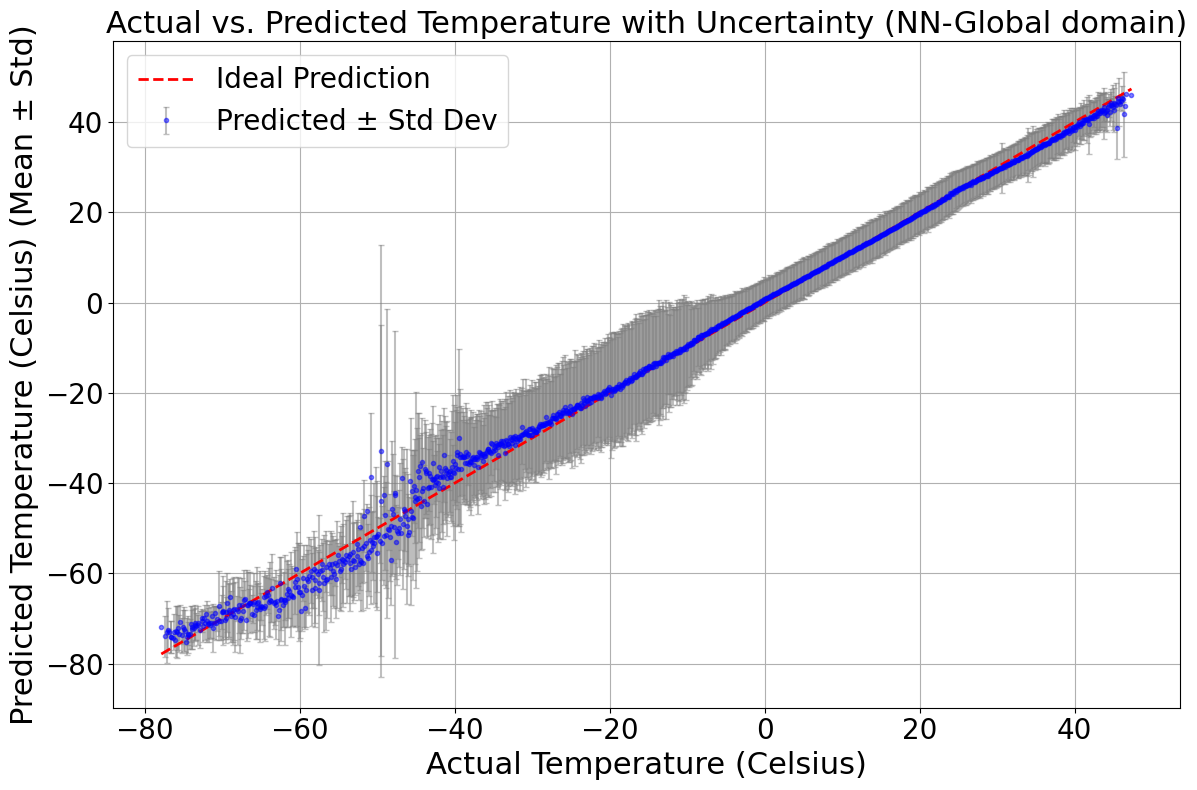

In [67]:
# Actual vs. Predicted Temperature with Uncertainty (NN-Global domain) 
plt.figure(figsize=(12, 8))
plt.errorbar(tempdf_grouped['y_test'], tempdf_grouped['predicted']['mean'], yerr=2*tempdf_grouped['predicted']['std'], fmt='o', alpha=0.5, markersize=3,
             ecolor='gray', capsize=2, label='Predicted ± Std Dev', color='blue')

# Reference line: perfect prediction
plt.plot([tempdf_grouped['y_test'].min(), tempdf_grouped['y_test'].max()], [tempdf_grouped['y_test'].min(), tempdf_grouped['y_test'].max()],'r--', label='Ideal Prediction', linewidth=2)

plt.xlabel('Actual Temperature (Celsius)', fontsize=22)
plt.ylabel('Predicted Temperature (Celsius) (Mean ± Std)', fontsize=22)
plt.title('Actual vs. Predicted Temperature with Uncertainty (NN-Global domain)', fontsize=22)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=20)
plt.grid(True)
plt.tight_layout()
plt.show()


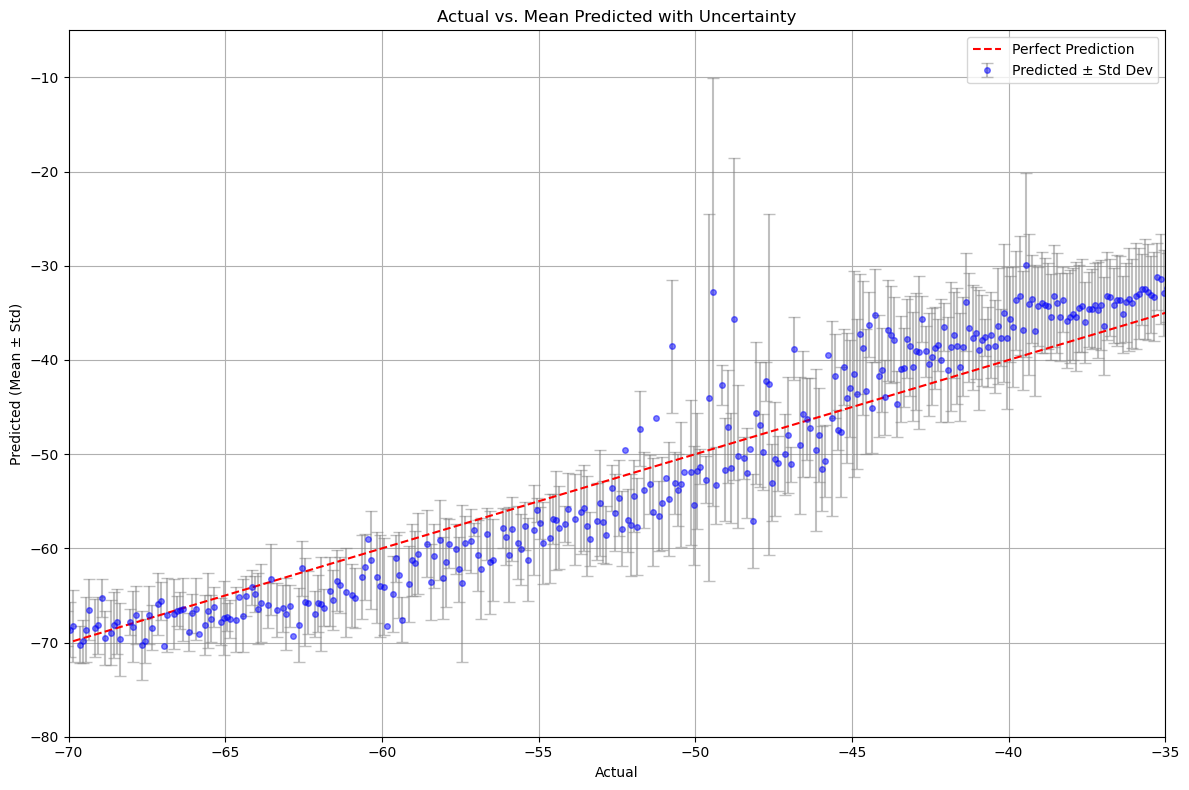

In [69]:
# Plot for -70 to -35 degree celsius (actual vs predicted temp)
errors = abs(tempdf_grouped['predicted']['mean'] - tempdf_grouped['y_test'])
#errors = errors.astype(int)
plt.figure(figsize=(12, 8))
plt.errorbar(tempdf_grouped['y_test'], tempdf_grouped['predicted']['mean'], yerr=tempdf_grouped['predicted']['std'], fmt='o', alpha=0.5, markersize=4,
             ecolor='gray', capsize=4, label='Predicted ± Std Dev', color='blue')

# Reference line: perfect prediction
plt.plot([tempdf_grouped['y_test'].min(), tempdf_grouped['y_test'].max()], [tempdf_grouped['y_test'].min(), tempdf_grouped['y_test'].max()],'r--', label='Perfect Prediction')

#plt.xscale('log')
#plt.yscale('log')
plt.xlim(-70,-35)
plt.ylim(-80,-5)
plt.xlabel('Actual')
plt.ylabel('Predicted (Mean ± Std)')
plt.title('Actual vs. Mean Predicted with Uncertainty')
plt.xlim
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Most of the residual outliers are in the range of -40 to -60 degrees. We need to check why this is the case. Let us check the number of observations in this range and also check the altitude variation to find if there is any pattern.

/var/folders/pw/b7xk2wbj2zlghgd_7c0zcfp40000gn/T/ipykernel_18069/999720758.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_bin_error = tempdf1.groupby([temp_bins])['error'].agg(['mean', 'std']).reset_index()


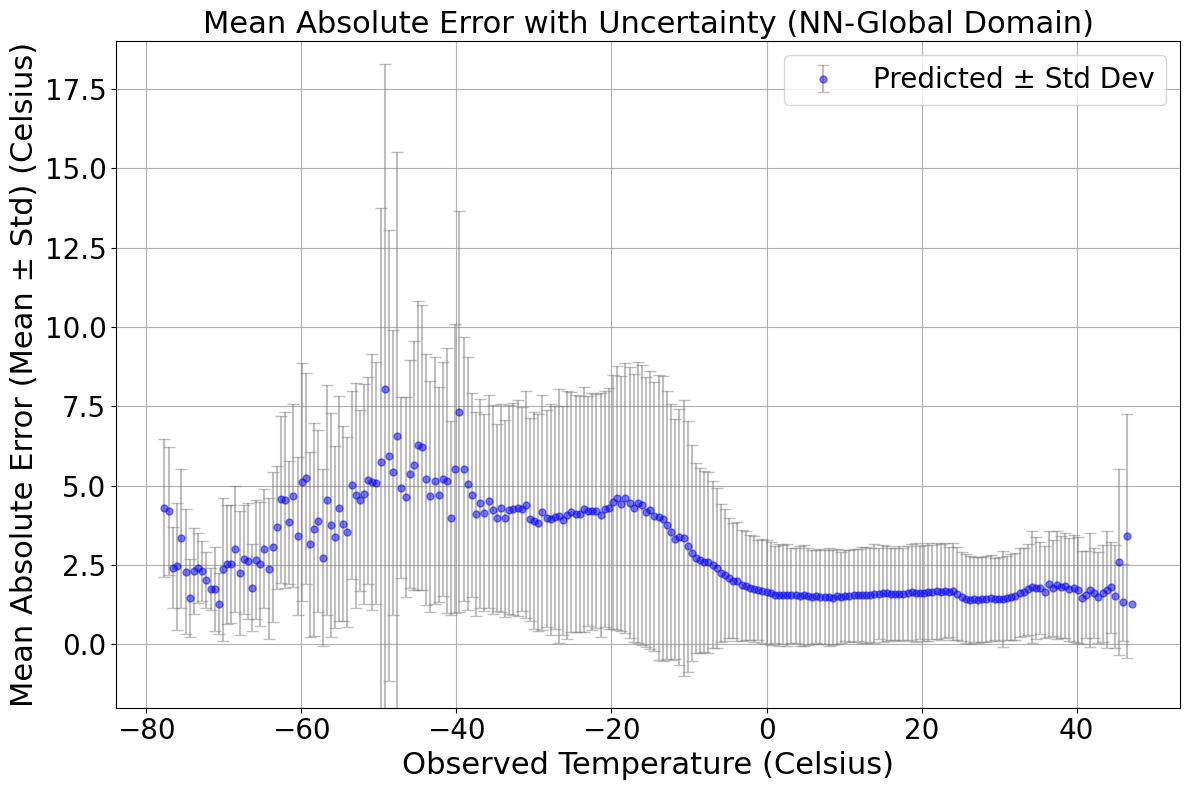

In [72]:
## Mean of MAE within temperature bins. the temperature range has been divided into 234 bins.
temp_bins = pd.cut(tempdf['y_test'], bins=234)
tempdf1 = tempdf.copy()
tempdf1['error'] = np.abs(tempdf1['error'])
temp_bin_error = tempdf1.groupby([temp_bins])['error'].agg(['mean', 'std']).reset_index()
temp_bin_error['temp_center'] = temp_bin_error['y_test'].apply(lambda x : x.mid)
temp_bin_error

plt.figure(figsize=(12, 8))
plt.errorbar(temp_bin_error['temp_center'], temp_bin_error['mean'], yerr=temp_bin_error['std'], fmt='o', alpha=0.5, markersize=5,
             ecolor='gray', capsize=4, label='Predicted ± Std Dev', color='blue')

# Reference line: perfect prediction
#plt.plot([tempdf_grouped['y_test'].min(), tempdf_grouped['y_test'].max()], [tempdf_grouped['y_test'].min(), tempdf_grouped['y_test'].max()],'r--', label='Perfect Prediction')

plt.ylim(-2,19)
#plt.ylim(-1,9)
plt.xlabel('Observed Temperature (Celsius)', fontsize=22)
plt.ylabel('Mean Absolute Error (Mean ± Std) (Celsius)', fontsize=22)
plt.title('Mean Absolute Error with Uncertainty (NN-Global Domain)', fontsize=22)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=20)
plt.grid(True)
plt.tight_layout()
plt.show()


/var/folders/pw/b7xk2wbj2zlghgd_7c0zcfp40000gn/T/ipykernel_18069/3277287175.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_bin_error = tempdf1.groupby([temp_bins])['error'].agg(['mean', 'std']).reset_index()


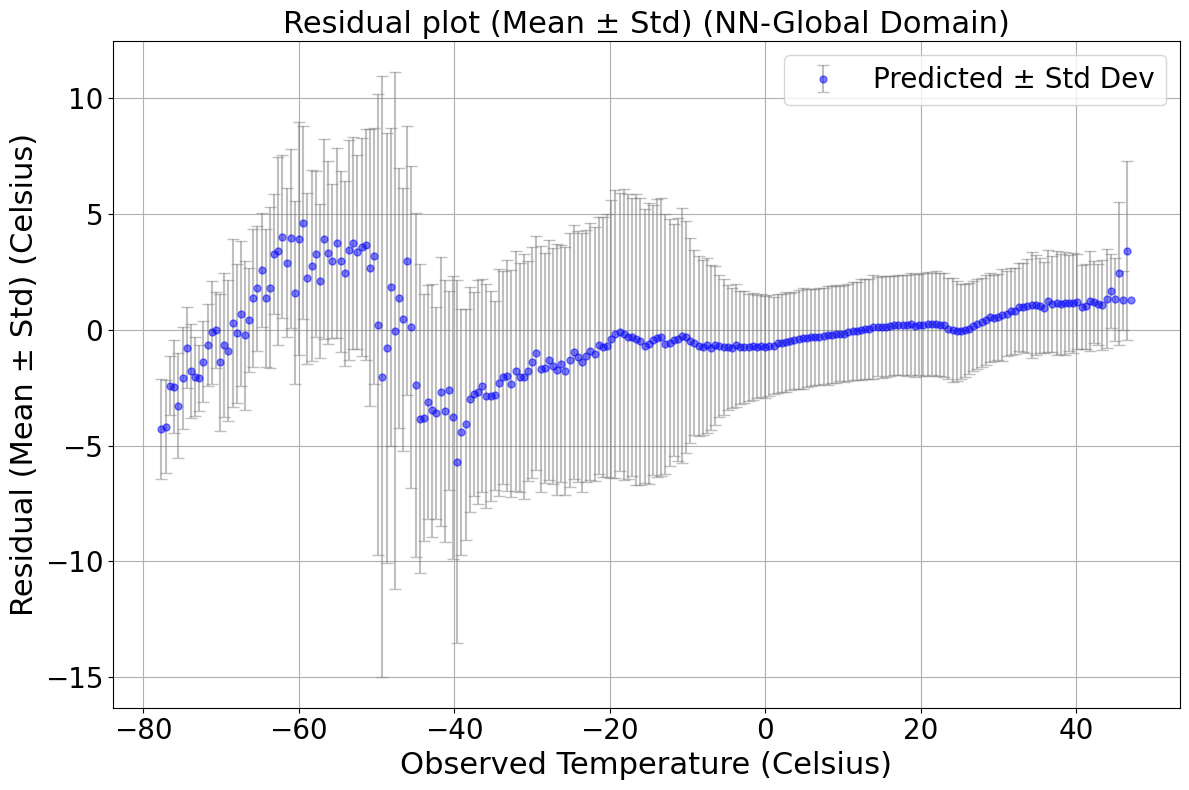

In [74]:
## Mean of residuals within temperature bins. the temperature range has been divided into 234 bins.
temp_bins = pd.cut(tempdf['y_test'], bins=234)
tempdf1 = tempdf.copy()
tempdf1['error'] = tempdf1['error']
temp_bin_error = tempdf1.groupby([temp_bins])['error'].agg(['mean', 'std']).reset_index()
temp_bin_error['temp_center'] = temp_bin_error['y_test'].apply(lambda x : x.mid)
temp_bin_error

plt.figure(figsize=(12, 8))
plt.errorbar(temp_bin_error['temp_center'], temp_bin_error['mean'], yerr=temp_bin_error['std'], fmt='o', alpha=0.5, markersize=5,
             ecolor='gray', capsize=4, label='Predicted ± Std Dev', color='blue')

# Reference line: perfect prediction
#plt.plot([tempdf_grouped['y_test'].min(), tempdf_grouped['y_test'].max()], [tempdf_grouped['y_test'].min(), tempdf_grouped['y_test'].max()],'r--', label='Perfect Prediction')

#plt.ylim(-2,19)
#plt.ylim(-1,9)
plt.xlabel('Observed Temperature (Celsius)', fontsize=22)
plt.ylabel('Residual (Mean ± Std) (Celsius)', fontsize=22)
plt.title('Residual plot (Mean ± Std) (NN-Global Domain)', fontsize=22)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=20)
plt.grid(True)
plt.tight_layout()
plt.show()


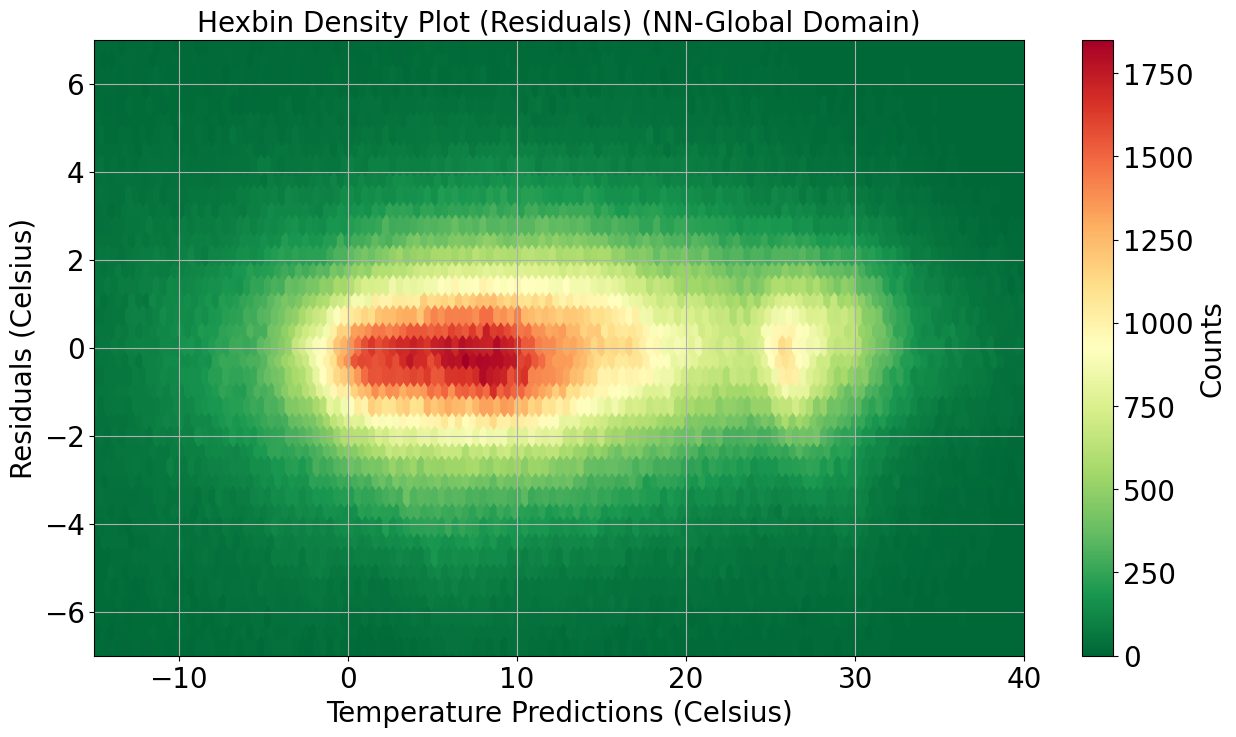

In [76]:
# Residual density plot
plt.figure(figsize=(15,8))
hb = plt.hexbin(
    tempdf['predicted'],
    tempdf['y_test'] - tempdf['predicted'],
    gridsize=300,
    cmap='RdYlGn_r'
)

cbar = plt.colorbar(hb)                 # get the colorbar for the hexbin
cbar.set_label('Counts', fontsize=20)   # label size
cbar.ax.tick_params(labelsize=20)       # TICK label size

plt.xlabel('Temperature Predictions (Celsius)', fontsize=20)
plt.ylabel('Residuals (Celsius)', fontsize=20)
plt.title('Hexbin Density Plot (Residuals) (NN-Global Domain)', fontsize=20)
plt.ylim(-7, 7)
plt.xlim(-15, 40)
plt.grid(True); plt.xticks(fontsize=20); plt.yticks(fontsize=20)
plt.show()


1402110


Text(0.5, 1.0, 'Residual Plot (-70 to -35 C Test values)')

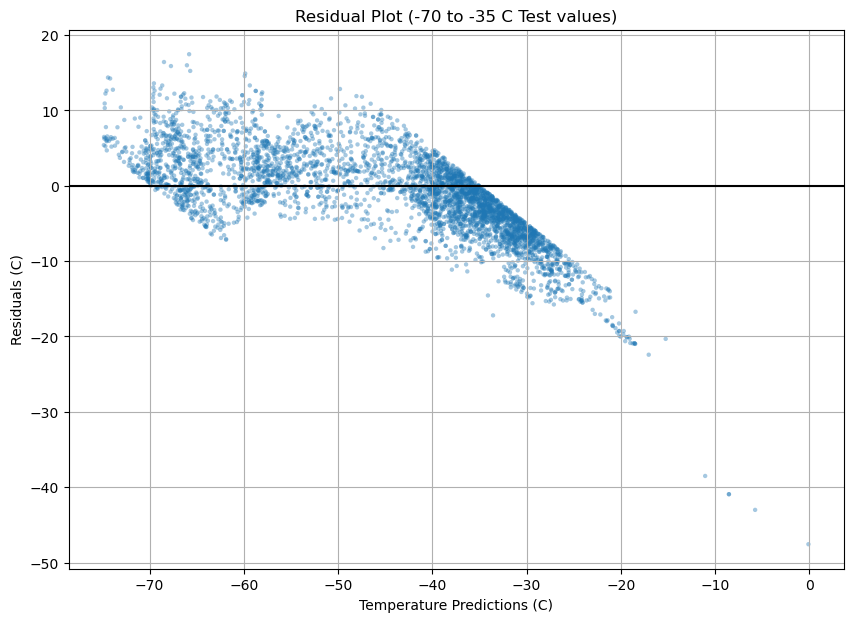

In [88]:
# Residual plot for observations from -70 to -35 degree celsius
low_temp_test_data = tempdf[(tempdf['y_test'] > -70) & (tempdf['y_test'] < -35)]
print(map_values.shape[0])
resids = low_temp_test_data['y_test'] - low_temp_test_data['predicted'] 

plt.figure(figsize=(10,7))
plt.scatter(low_temp_test_data['predicted'], resids, s=10, alpha=0.4, edgecolors='none')
plt.axhline(y=0, color='black')
plt.grid(True)
#plt.ylim((-20,40))
plt.xlabel('Temperature Predictions (C)')
plt.ylabel('Residuals (C)')
plt.title('Residual Plot (-70 to -35 C Test values)')

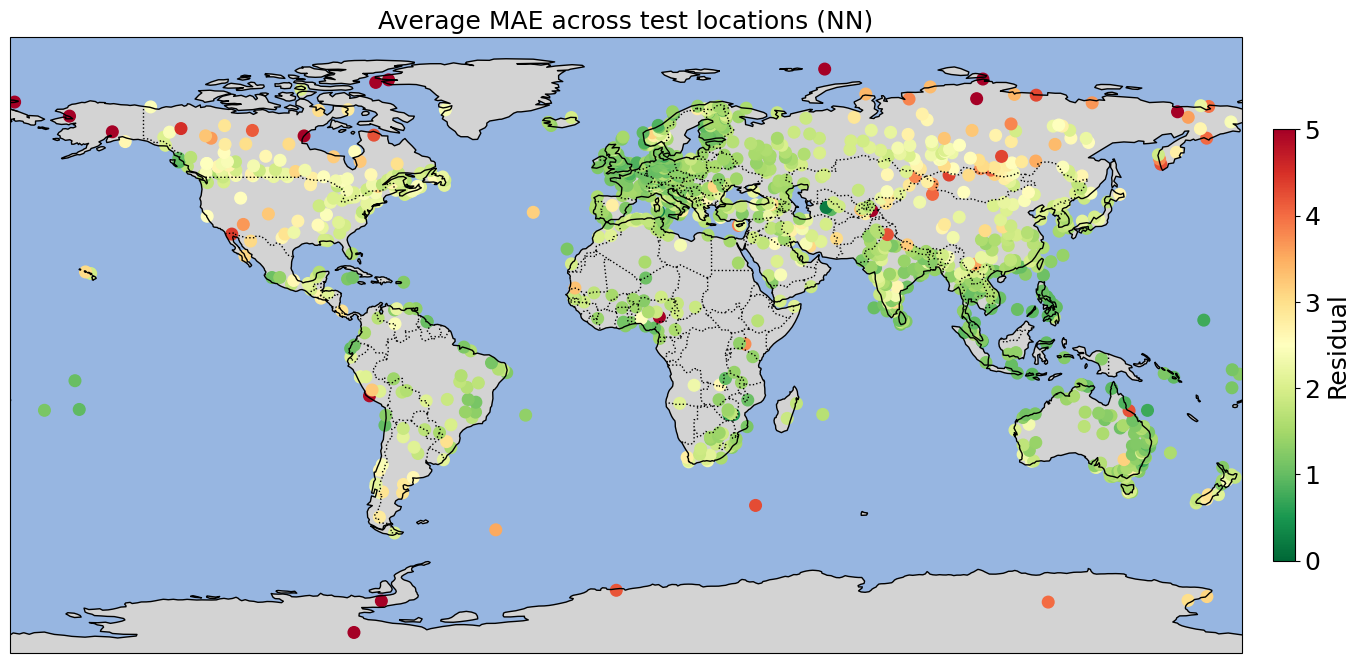

In [86]:
# MAE spatial distribution map
unique_test_locs = tempdf.copy()
unique_test_locs['error'] = np.abs(unique_test_locs['error'])
unique_test_locs = unique_test_locs.groupby(['latitude', 'longitude'])['error'].mean().reset_index()

# Create a map
plt.figure(figsize=(20, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
#ax.set_extent([-11, 3, 49.5, 61.5], crs=ccrs.PlateCarree())
# Add features: coastlines, borders, land, ocean
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)
ax.set_global()
z = np.abs(unique_test_locs['error'])
# Plot points
sc = ax.scatter(unique_test_locs['longitude'], unique_test_locs['latitude'], s=70, c=z, alpha=1, transform=ccrs.PlateCarree(), cmap='RdYlGn_r', vmin=0, vmax=5)

# Colorbar for residual intensity
#plt.colorbar(sc, ax=ax, orientation='vertical', label='Residual')
plt.title("Average MAE across test locations (NN)", fontsize=18)
cbar = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.02, shrink=0.7)
cbar.set_label('Residual', fontsize=18)   # colorbar title size
cbar.ax.tick_params(labelsize=18) 
plt.show()

Text(0.5, 1.0, 'Residual Plot')

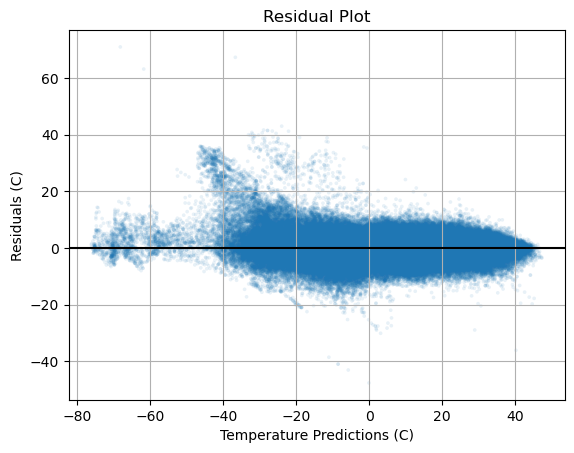

In [93]:
# Basic residual plot
resids = tempdf['y_test'] - tempdf['predicted'] 
plt.scatter(tempdf['predicted'], resids, s=7, alpha=0.1, edgecolors='none')
plt.axhline(y=0, color='black')
plt.grid(True)
#plt.ylim((-20,40))
plt.xlabel('Temperature Predictions (C)')
plt.ylabel('Residuals (C)')
plt.title('Residual Plot')

#### Error variation with day of year

In [138]:
# creating a dataframe to store results grouped by day of year
tempdf_grouped_doy = tempdf.copy()
tempdf_grouped_doy['error'] = np.abs(tempdf_grouped_doy['error'])
tempdf_grouped_doy = tempdf_grouped_doy.groupby(['latitude', 'longitude', 'day_of_year'], as_index = False).agg({
    'error' : ['mean', 'std']
})

site1 = tempdf_grouped_doy[(tempdf_grouped_doy['latitude'] == 52.08) & (tempdf_grouped_doy['longitude'] == -2.803)]
site2 = tempdf_grouped_doy[(tempdf_grouped_doy['latitude'] == -42.906000) & (tempdf_grouped_doy['longitude'] == -71.145000)]

tempdf_grouped_doy

latitude longitude day_of_year     error          
                                           mean       std
0       -84.000   -79.494          32  3.748242  0.913378
1       -84.000   -79.494          33  4.190912  1.200901
2       -84.000   -79.494          34  1.869628  0.851419
3       -84.000   -79.494          35  2.421776  0.916837
4       -84.000   -79.494          36  1.697171  0.538679
...         ...       ...         ...       ...       ...
121252   80.626    58.059         136  2.217438  1.345633
121253   80.626    58.059         137  1.313904  1.185892
121254   80.626    58.059         138  0.897835  0.424041
121255   80.626    58.059         139  1.110835  0.391264
121256   80.626    58.059         140  0.781643  0.286262

[121257 rows x 5 columns]

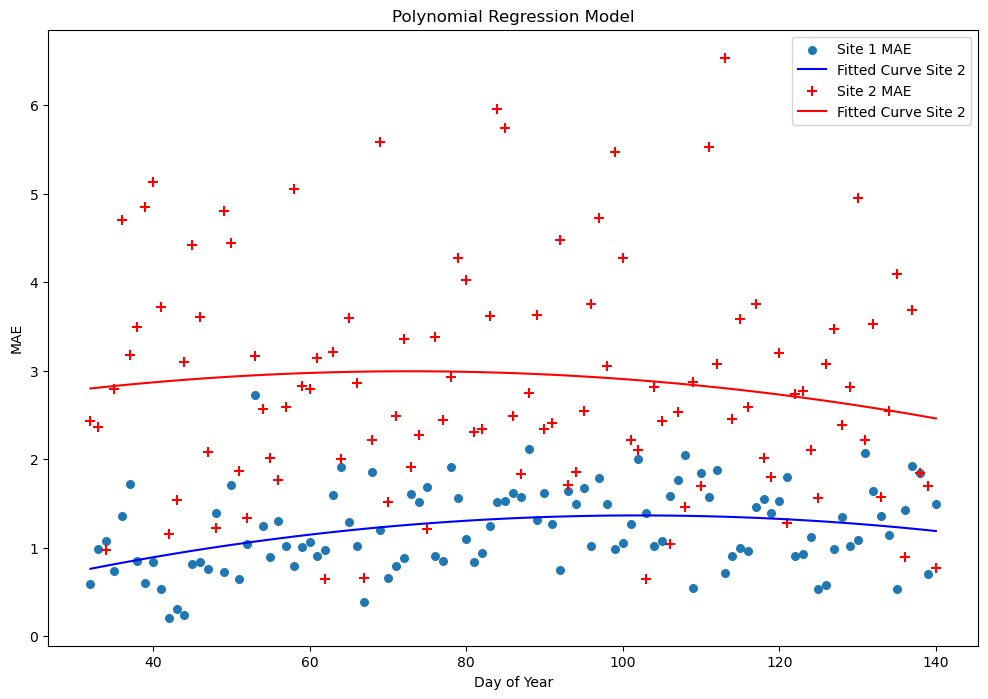

In [148]:
#Plotting MAE time series for two different sites
#site 1
x = np.array(site1['day_of_year']).reshape(-1, 1)
y = np.array(site1['error']['mean']).reshape(-1, 1)

#Transforming the input features to include additional terms such as x^2 and intercept
transformer = PolynomialFeatures(degree=2, include_bias=True)
transformer.fit(x)
x_ = transformer.transform(x)

model = LinearRegression().fit(x_, y)
r_sq = model.score(x_, y)

#Generate smooth x values
x_smooth = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
x_smooth_poly = transformer.transform(x_smooth)

y_pred = model.predict(x_smooth_poly)
plt.figure(figsize=(12,8))
plt.scatter(x, y, label='Site 1 MAE', s = 30, alpha = 1)
plt.plot(x_smooth, y_pred, color='blue', label='Fitted Curve Site 2')



#site2
x = np.array(site2['day_of_year']).reshape(-1,1)
y = np.array(site2['error']['mean']).reshape(-1,1)

#Transforming the input features to include additional terms such as x^2 and intercept
transformer = PolynomialFeatures(degree=2, include_bias=True)
transformer.fit(x)
x_ = transformer.transform(x)

model = LinearRegression().fit(x_, y)
r_sq = model.score(x_, y)

#Generate smooth x values
x_smooth = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
x_smooth_poly = transformer.transform(x_smooth)

y_pred = model.predict(x_smooth_poly)
plt.scatter(x, y, label='Site 2 MAE', s = 50, alpha = 1, marker='+', color='red')
plt.plot(x_smooth, y_pred, color='red', label='Fitted Curve Site 2')
plt.legend()
plt.xlabel("Day of Year")
plt.ylabel("MAE")
plt.title("Polynomial Regression Model")
plt.show()


/opt/anaconda3/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1692: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  result = super().scatter(*args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1692: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  result = super().scatter(*args, **kwargs)


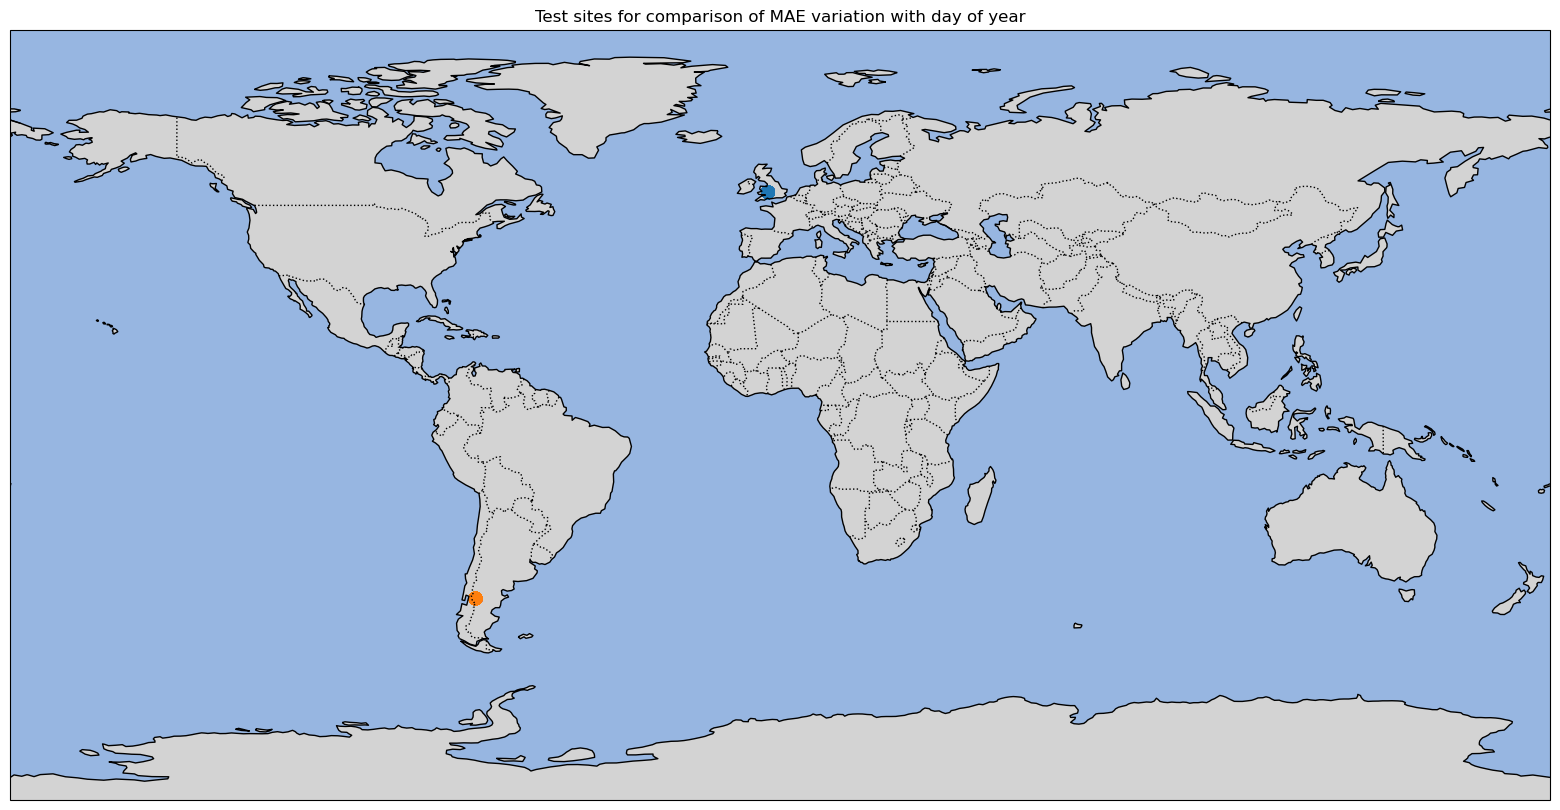

In [142]:
# Create a map showing the location of the two sites.
plt.figure(figsize=(20, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-8.5, 1.8, 49.8, 61.5], crs=ccrs.PlateCarree())
# Add features: coastlines, borders, land, ocean
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)
ax.set_global()
#z = np.abs(unique_test_locs['error'])
# Plot points
sc = ax.scatter(site1['longitude'], site1['latitude'], s=100,  alpha=1, transform=ccrs.PlateCarree(), cmap='RdYlGn_r', vmin=0, vmax=5, edgecolor='none')
sc = ax.scatter(site2['longitude'], site2['latitude'], s=100,  alpha=1, transform=ccrs.PlateCarree(), cmap='RdYlGn_r', vmin=0, vmax=5, edgecolor='none')

plt.title("Test sites for comparison of MAE variation with day of year")
plt.show()